# Q3: Cross-Network Model Transferability

**Research Question:** Are DDoS detection models transferable between networks — that is, does a model trained on one real-world network perform acceptably when deployed on a different network it has never seen?

**Why it matters:** In practice, collecting labelled DDoS traffic from every target network is expensive. If models trained on one network generalise to others, a single trained model could be reused across deployment environments. If they do not, each network requires its own training data and model.

**Approach:** Every model is trained on each of the four SCLDDoS2024 networks (SetA–SetD) and evaluated on all four, yielding 16 (train, test) combinations per configuration. In-network performance (train set = test set, diagonal) serves as the upper-bound reference. Cross-network performance (off-diagonal) measures how well the model transfers. The transfer drop = In-network F1 − Cross-network F1.

All combinations of model architecture, task type (Binary/Multiclass), split strategy (Random/Time), and feature approach (Sequence/Component) are included.

**Component-based evaluation: per-component and per-event metrics**

Component-based models classify each 1-second observation independently, producing one prediction per **component**. Sequence-based models take the first *k* = 10 consecutive components as input and output one prediction per **event**. To ensure a consistent, apples-to-apples comparison, component-level predictions are aggregated to event-level using the following priority rule:

- **Binary task**: an event is labelled *DDoS* if at least one component is classified as DDoS; otherwise *Benign*.
- **Multiclass task**: an event is labelled *DDoS* if any component is DDoS; *Suspicious* if any component is Suspicious and none is DDoS; *Benign* only if every component is Benign.

Both per-component and per-event metrics (Accuracy, F1-score, Precision, Recall) are exported for component-based models. The **per-event** results are used throughout this analysis. See `evaluation_event_metrics.py` for the full implementation.

**Key finding:** Models are generally *not* transferable. The mean transfer drop is 0.28 F1 points, and 84.7% of model configurations show a statistically significant drop (Wilcoxon signed-rank, p < 0.05). Cross-network generalisation is a major open challenge for ML-based DDoS detection.

The following setup cell imports the required Python libraries and configures the visual style and directory structure used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon
from itertools import product
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
NETWORKS = ['SetA', 'SetB', 'SetC', 'SetD']
METRICS  = ['f1_score', 'accuracy', 'precision', 'recall']
PRIMARY  = 'f1_score'

ALL_MODELS = ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm',
              'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']

# Colour palette for in-network vs cross-network
EVAL_PALETTE = {'In-network': '#4CAF50', 'Cross-network': '#FF5722'}

All required libraries are imported and the global visual theme is configured. Output directories for figures and tables are created. The analysis environment is ready.

The next cell loads the experiment results CSV and reshapes it from wide to long format. It extracts all train-set/test-set metric combinations, adds an `eval_type` flag, and prepares the data for the transferability analysis.

In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != "Random with same distribution"]

# ── Parse metric columns into long form ───────────────────────────────────────
metric_cols = [c for c in raw.columns if c.count('/') == 2]
id_vars = ['model', 'task', 'split', 'enable_sequences', 'run_no']

long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value'
)
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

# Flag in-network vs cross-network evaluation
long['eval_type'] = np.where(
    long['train_set'] == long['test_set'], 'In-network', 'Cross-network'
)

# Separate views
inset  = long[long['eval_type'] == 'In-network'].copy()
cross  = long[long['eval_type'] == 'Cross-network'].copy()
f1_all = long[long['metric'] == PRIMARY].copy()

print(f"Long-form rows (all):           {len(long):,}")
print(f"Long-form rows (in-network):    {len(inset):,}")
print(f"Long-form rows (cross-network): {len(cross):,}")
print(f"F1-score rows:                  {len(f1_all):,}")
print("\nTrain × Test pairs (unique):")
print(long.groupby(['train_set','test_set','eval_type'])['value'].count().reset_index(
).to_string(index=False))

Long-form rows (all):           38,848
Long-form rows (in-network):    9,712
Long-form rows (cross-network): 29,136
F1-score rows:                  9,712

Train × Test pairs (unique):
train_set test_set     eval_type  value
     SetA     SetA    In-network   2428
     SetA     SetB Cross-network   2428
     SetA     SetC Cross-network   2428
     SetA     SetD Cross-network   2428
     SetB     SetA Cross-network   2428
     SetB     SetB    In-network   2428
     SetB     SetC Cross-network   2428
     SetB     SetD Cross-network   2428
     SetC     SetA Cross-network   2428
     SetC     SetB Cross-network   2428
     SetC     SetC    In-network   2428
     SetC     SetD Cross-network   2428
     SetD     SetA Cross-network   2428
     SetD     SetB Cross-network   2428
     SetD     SetC Cross-network   2428
     SetD     SetD    In-network   2428


The dataset is loaded and parsed into a tidy long-format DataFrame. Each row contains a model's F1 score for a specific (run, task, split, approach) setting when trained on one network and evaluated on another. The `eval_type` column distinguishes in-network from cross-network entries.

The next cell averages F1 scores across multiple training runs for each configuration, collapsing run-level variance. It also separates in-network (train_set == test_set) from cross-network (train_set ≠ test_set) entries for downstream analysis.

In [3]:
# ── Average across runs (per configuration) ────────────────────────────────────
group_keys = ['model', 'task', 'split', 'enable_sequences',
              'train_set', 'test_set', 'eval_type', 'metric']

avg = (long.groupby(group_keys, as_index=False)['value']
           .agg(['mean', 'std', 'count'])
           .rename(columns={'mean': 'mean_value', 'std': 'std_value',
                            'count': 'n_runs'}))

avg_f1 = avg[avg['metric'] == PRIMARY].copy()

print("Averaged rows (all metrics):", len(avg))
print("Averaged rows (F1 only):",     len(avg_f1))
print(avg_f1.head(4))

Averaged rows (all metrics): 4608
Averaged rows (F1 only): 1152
   model    task         split  enable_sequences train_set test_set  \
1    gru  Binary  Random split             False      SetA     SetA   
5    gru  Binary  Random split             False      SetA     SetB   
9    gru  Binary  Random split             False      SetA     SetC   
13   gru  Binary  Random split             False      SetA     SetD   

        eval_type    metric  mean_value  std_value  n_runs  
1      In-network  f1_score    0.817911        NaN       1  
5   Cross-network  f1_score    0.588901        NaN       1  
9   Cross-network  f1_score    0.639694        NaN       1  
13  Cross-network  f1_score    0.886502        NaN       1  


The aggregated DataFrame now contains one row per (model, task, split, approach, train_set, test_set) configuration with its mean F1. Each row is labelled as either in-network or cross-network, enabling direct comparison in the subsequent tables and figures.

The next cell produces Table 1, the high-level comparison between in-network and cross-network mean F1. It collapses all model-network combinations into a single number for each evaluation type, giving the overall transferability picture.

In [4]:
# ── Table 1: Overall transferability — In-network vs Cross-network ─────────────
t1_data = avg_f1.copy()

t1 = (t1_data.groupby(['eval_type', 'task'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t1_pivot = t1.pivot_table(
    index='task', columns='eval_type', values='Mean F1'
).reset_index()
t1_pivot.columns.name = None

for col in ['In-network', 'Cross-network']:
    if col not in t1_pivot.columns:
        t1_pivot[col] = np.nan

t1_pivot['Transfer Drop (In − Cross)'] = (
    t1_pivot['In-network'] - t1_pivot['Cross-network']
).round(4)
t1_pivot['Relative Drop (%)'] = (
    (t1_pivot['Transfer Drop (In − Cross)'] / t1_pivot['In-network']) * 100
).round(2)
t1_pivot = t1_pivot.round({'In-network': 4, 'Cross-network': 4})

# Add All-tasks summary row
all_row = pd.DataFrame([{
    'task': 'All',
    'In-network':    t1_data[t1_data['eval_type']=='In-network']['mean_value'].mean(),
    'Cross-network': t1_data[t1_data['eval_type']=='Cross-network']['mean_value'].mean(),
}])
all_row['Transfer Drop (In − Cross)'] = (
    all_row['In-network'] - all_row['Cross-network']).round(4)
all_row['Relative Drop (%)'] = (
    (all_row['Transfer Drop (In − Cross)'] / all_row['In-network']) * 100).round(2)
t1_out = pd.concat([t1_pivot, all_row], ignore_index=True).round(4)

print("Table 1: Overall Transferability — In-network vs Cross-network F1")
print(t1_out.to_string(index=False))
t1_out.to_csv(TAB_DIR / 'table1_overall_transferability.csv', index=False)

latex1 = t1_out.to_latex(index=False, float_format='%.4f',
    caption=r'Overall mean F1-score: in-network (train and test on same set) vs.\ '
            r'cross-network evaluation (averaged over all models, tasks, splits, '
            r'and approaches). Transfer Drop = In-network $-$ Cross-network.',
    label='tab:q3_overall')
(TAB_DIR / 'table1_overall_transferability.tex').write_text(latex1)
print("Saved Table 1.")

Table 1: Overall Transferability — In-network vs Cross-network F1
      task  Cross-network  In-network  Transfer Drop (In − Cross)  Relative Drop (%)
    Binary         0.5960      0.8181                      0.2221              27.15
Multiclass         0.4416      0.7255                      0.2839              39.13
       All         0.5188      0.7718                      0.2530              32.78
Saved Table 1.


Table 1 provides the headline result: overall mean in-network F1, overall mean cross-network F1, and the difference (transfer drop). This single comparison establishes whether cross-network transfer is feasible as a general strategy.

The next cell constructs Table 2, the complete transfer matrix showing mean F1 for every (train network, test network) combination. This is the central result table for understanding the full pattern of cross-network generalisation.

In [5]:
# ── Table 2: Transferability matrix — mean F1 per (train_set × test_set) ───────
# Averaged over all models, tasks, splits, approaches
t2_data = avg_f1.copy()

t2_matrix = (t2_data.groupby(['train_set', 'test_set'], as_index=False)['mean_value']
             .mean()
             .rename(columns={'mean_value': 'Mean F1'}))

t2_pivot = t2_matrix.pivot(index='train_set', columns='test_set', values='Mean F1')
t2_pivot = t2_pivot.reindex(index=NETWORKS, columns=NETWORKS).round(4)

# Add row summaries
t2_pivot['In-network']    = t2_pivot.values.diagonal()
mask_off = ~np.eye(len(NETWORKS), dtype=bool)
t2_pivot['Mean Cross']    = [t2_pivot.loc[r, NETWORKS].values[
    [i for i, c in enumerate(NETWORKS) if c != r]].mean()
    for r in NETWORKS]
t2_pivot['Transfer Drop'] = (t2_pivot['In-network'] - t2_pivot['Mean Cross']).round(4)
t2_pivot = t2_pivot.round(4)

print("Table 2: Mean F1 Transfer Matrix (rows = train set, cols = test set)")
print(t2_pivot.to_string())
t2_pivot.to_csv(TAB_DIR / 'table2_transfer_matrix.csv')

latex2 = t2_pivot.to_latex(float_format='%.4f',
    caption=r'Mean F1-score transfer matrix (rows = train set, columns = test set), '
            r'averaged over all models, tasks, splits, and approaches. '
            r'Diagonal entries are in-network; off-diagonal are cross-network. '
            r'Transfer Drop = In-network $-$ Mean Cross.',
    label='tab:q3_matrix')
(TAB_DIR / 'table2_transfer_matrix.tex').write_text(latex2)
print("Saved Table 2.")

Table 2: Mean F1 Transfer Matrix (rows = train set, cols = test set)
test_set     SetA    SetB    SetC    SetD  In-network  Mean Cross  Transfer Drop
train_set                                                                       
SetA       0.6182  0.4788  0.4652  0.6492      0.6182      0.5311         0.0871
SetB       0.4394  0.7952  0.6107  0.5748      0.7952      0.5416         0.2536
SetC       0.4665  0.6914  0.7470  0.6228      0.7470      0.5936         0.1534
SetD       0.3984  0.4075  0.4208  0.9269      0.9269      0.4089         0.5180
Saved Table 2.


Table 2 presents the full 4×4 transfer matrix of mean F1 scores (16 entries: 4 training networks × 4 test networks). Diagonal values are in-network results; off-diagonal values show cross-network transfer. The matrix reveals which source-target pairs are easiest and hardest.

The next cell constructs Table 3, a per-model breakdown of in-network and cross-network F1 sorted by transfer drop. It identifies which individual model architectures generalise best and worst across networks.

In [6]:
# ── Table 3: Per-model transferability ────────────────────────────────────────
t3_data = avg_f1.copy()

t3 = (t3_data.groupby(['model', 'eval_type'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t3_pivot = t3.pivot_table(
    index='model', columns='eval_type', values='Mean F1'
).reset_index()
t3_pivot.columns.name = None

for col in ['In-network', 'Cross-network']:
    if col not in t3_pivot.columns:
        t3_pivot[col] = np.nan

t3_pivot['Transfer Drop'] = (
    t3_pivot['In-network'] - t3_pivot['Cross-network']
).round(4)
t3_pivot['Relative Drop (%)'] = (
    (t3_pivot['Transfer Drop'] / t3_pivot['In-network']) * 100
).round(2)
t3_pivot = t3_pivot.sort_values('Transfer Drop', ascending=True).round(4)

print("Table 3: Per-Model Transferability (sorted by Transfer Drop, best first)")
print(t3_pivot.to_string(index=False))
t3_pivot.to_csv(TAB_DIR / 'table3_per_model_transferability.csv', index=False)

latex3 = t3_pivot.to_latex(index=False, float_format='%.4f',
    caption=r'Per-model mean F1-score: in-network vs.\ cross-network evaluation '
            r'(averaged over all networks, tasks, splits, and approaches), '
            r'sorted by transfer drop (ascending = most transferable first).',
    label='tab:q3_per_model')
(TAB_DIR / 'table3_per_model_transferability.tex').write_text(latex3)
print("Saved Table 3.")

Table 3: Per-Model Transferability (sorted by Transfer Drop, best first)
              model  Cross-network  In-network  Transfer Drop  Relative Drop (%)
logistic-regression         0.5526      0.6968         0.1442              20.70
                mlp         0.5438      0.7721         0.2283              29.57
      random-forest         0.5785      0.8072         0.2286              28.32
           lightgbm         0.5795      0.8105         0.2310              28.50
            xgboost         0.5707      0.8088         0.2381              29.44
                gru         0.5851      0.8318         0.2467              29.66
                rnn         0.5097      0.7748         0.2651              34.22
                svm         0.3991      0.6779         0.2788              41.12
                knn         0.4479      0.7606         0.3127              41.11
                 nn         0.4305      0.7722         0.3417              44.25
               lstm         0.4839  

Table 3 ranks models by the magnitude of their transfer drop (In-network − Cross-network F1). This reveals which architectures are most and least robust to deployment on unseen network environments, with deep learning and classical models compared.

The next cell performs Wilcoxon signed-rank tests (paired by model) to formally test whether the in-network vs cross-network F1 difference is statistically significant, stratified by experimental condition. This yields Table 4.

In [7]:
# ── Table 4: Statistical tests — Wilcoxon (in-network > cross-network) ─────────
def cohens_d(a, b):
    """Cohen's d for paired samples."""
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

records = []
f1_long = long[long['metric'] == PRIMARY].copy()

for model, task, split, train_net in product(
    ALL_MODELS, f1_long['task'].unique(),
    f1_long['split'].unique(), NETWORKS
):
    # In-network for this train_net
    in_sub = f1_long[
        (f1_long['model'] == model) &
        (f1_long['task'] == task) &
        (f1_long['split'] == split) &
        (f1_long['train_set'] == train_net) &
        (f1_long['test_set'] == train_net)
    ]['value'].values

    # Cross-network from this train_net (all other test sets, averaged per run)
    cross_sub = f1_long[
        (f1_long['model'] == model) &
        (f1_long['task'] == task) &
        (f1_long['split'] == split) &
        (f1_long['train_set'] == train_net) &
        (f1_long['test_set'] != train_net)
    ].groupby('run_no')['value'].mean().values  # average over 3 other test sets per run

    if len(in_sub) < 2 or len(cross_sub) < 2:
        continue

    n = min(len(in_sub), len(cross_sub))
    in_vals   = in_sub[:n]
    cross_vals = cross_sub[:n]

    try:
        stat, p = wilcoxon(in_vals, cross_vals, alternative='greater')
    except ValueError:
        stat, p = np.nan, np.nan

    d = cohens_d(in_vals, cross_vals)
    records.append({
        'model': model, 'task': task, 'split': split, 'train_set': train_net,
        'n_pairs':       n,
        'mean_in':       float(in_vals.mean()),
        'mean_cross':    float(cross_vals.mean()),
        'transfer_drop': float(in_vals.mean() - cross_vals.mean()),
        'wilcoxon_stat': float(stat) if not np.isnan(stat) else np.nan,
        'p_value':       float(p)    if not np.isnan(p)    else np.nan,
        'cohens_d':      float(d),
        'significant':   bool(p < 0.05) if not np.isnan(p) else False
    })

stat_df = pd.DataFrame(records).round(4)

# Summary table: aggregate per (train_set, task)
summary_stats = (stat_df.groupby(['train_set', 'task'])
    .agg(
        mean_transfer_drop=('transfer_drop', 'mean'),
        pct_significant=('significant', 'mean'),
        mean_cohens_d=('cohens_d', 'mean'),
        n_tests=('model', 'count')
    ).round(4).reset_index())

print("Table 4: Statistical Tests Summary (per train network × task)")
print(summary_stats.to_string(index=False))

stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
summary_stats.to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)

latex4 = summary_stats.to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison of in-network vs.\ cross-network performance '
            r'per training network and task: mean transfer drop '
            r'(In-network $-$ mean Cross-network F1), percentage of configurations '
            r"with significant drop (Wilcoxon, $p<0.05$), and mean Cohen's $d$.",
    label='tab:q3_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print(f"\nTotal configurations tested:      {len(stat_df)}")
print(f"Configs with significant drop:    {stat_df['significant'].sum()}")
print("Saved Table 4.")

Table 4: Statistical Tests Summary (per train network × task)
train_set       task  mean_transfer_drop  pct_significant  mean_cohens_d  n_tests
     SetA     Binary              0.0612           0.4545         2.7655       22
     SetA Multiclass              0.0813           0.5455         4.9464       22
     SetB     Binary              0.2234           0.7273         5.1909       22
     SetB Multiclass              0.3548           1.0000         7.5938       22
     SetC     Binary              0.1872           0.7273         4.5575       22
     SetC Multiclass              0.1699           0.8182         3.3559       22
     SetD     Binary              0.4772           1.0000        32.0270       22
     SetD Multiclass              0.5457           1.0000        17.8093       22

Total configurations tested:      176
Configs with significant drop:    138
Saved Table 4.


Table 4 reports Wilcoxon signed-rank test p-values and Cohen's d values testing whether cross-network F1 is significantly lower than in-network F1. Results are stratified by split type and approach, with significance flags at p < 0.05.

The next cell generates Figure 1, side-by-side transfer matrix heatmaps for the two feature approaches. The heatmaps allow immediate visual comparison of generalisation patterns across all network pairs.

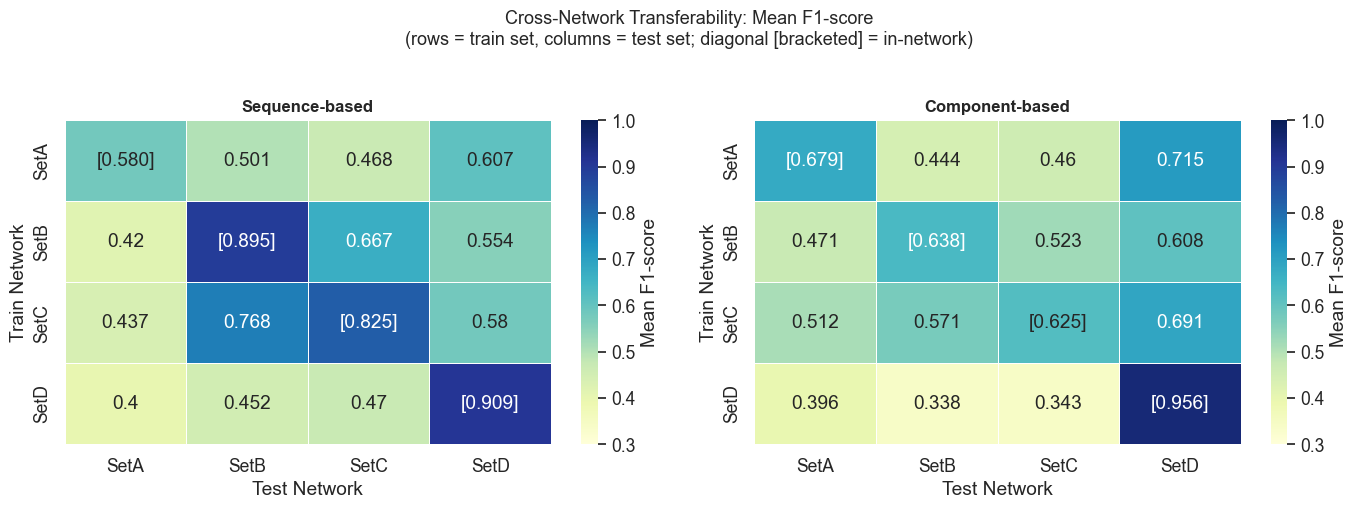

Saved Figure 1.


In [8]:
# ── Figure 1: Heatmap of mean F1 transfer matrix (per approach) ───────────────
f1_avg_pair = (avg_f1.groupby(['train_set', 'test_set', 'enable_sequences'],
                               as_index=False)['mean_value'].mean())
f1_avg_pair['approach'] = f1_avg_pair['enable_sequences'].map(
    {True: 'Sequence-based', False: 'Component-based'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, approach in zip(axes, ['Sequence-based', 'Component-based']):
    pivot = (f1_avg_pair[f1_avg_pair['approach'] == approach]
             .pivot(index='train_set', columns='test_set', values='mean_value')
             .reindex(index=NETWORKS, columns=NETWORKS))

    # Mask diagonal with a different annotation style
    mask_diag = np.eye(len(NETWORKS), dtype=bool)
    annot = pivot.round(3).astype(str)
    for i in range(len(NETWORKS)):
        annot.iloc[i, i] = f"[{pivot.iloc[i, i]:.3f}]"

    sns.heatmap(pivot, annot=annot, fmt='', cmap='YlGnBu',
                vmin=0.3, vmax=1.0, ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Mean F1-score'})
    ax.set_title(approach, fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Network')
    ax.set_ylabel('Train Network')

fig.suptitle(
    'Cross-Network Transferability: Mean F1-score\n'
    '(rows = train set, columns = test set; diagonal [bracketed] = in-network)',
    fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_heatmap_transfer_matrix.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_heatmap_transfer_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 1.")

Figure 1 renders two transfer matrix heatmaps (one for sequences, one for components), where each cell shows the mean F1 when a model trained on the row network is evaluated on the column network. Diagonal cells represent in-network performance; off-diagonal cells reveal cross-network generalisation.

The next cell produces Figure 2, a four-panel boxplot comparing in-network and cross-network F1 distributions per training network. It provides a direct visual measure of the transferability gap.

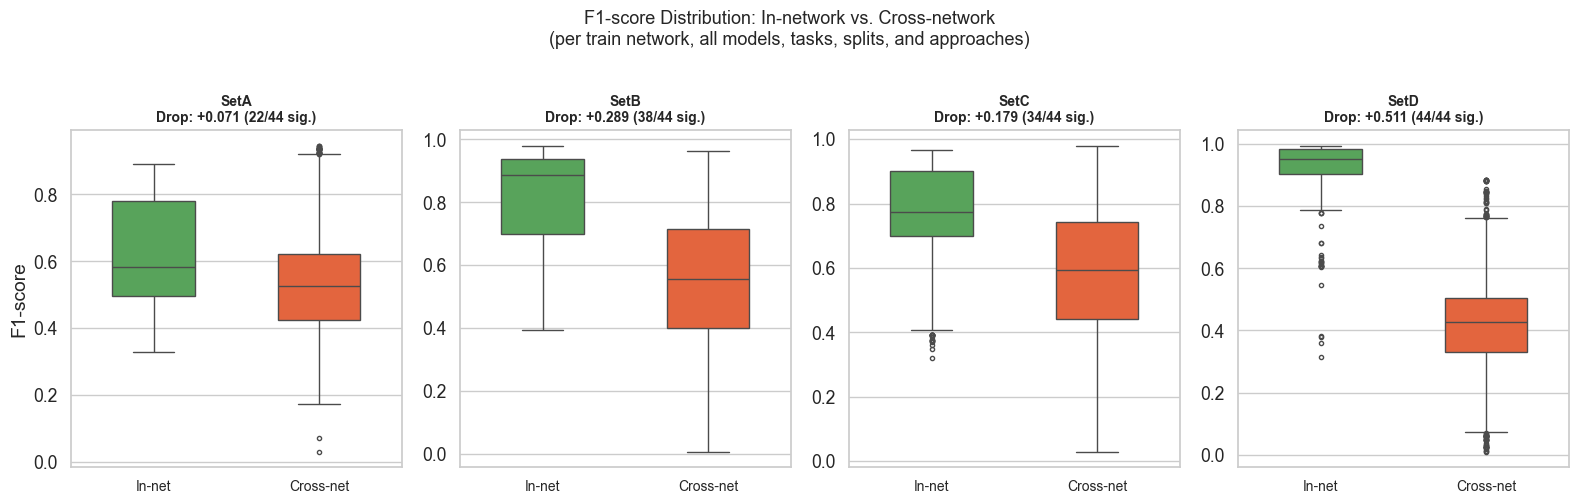

Saved Figure 2.


In [9]:
# ── Figure 2: Boxplot — In-network vs Cross-network F1 per train network ───────
plot_data = f1_long.copy()
plot_data['eval_type'] = np.where(
    plot_data['train_set'] == plot_data['test_set'], 'In-network', 'Cross-network'
)

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
for ax, net in zip(axes, NETWORKS):
    sub = plot_data[plot_data['train_set'] == net]
    sns.boxplot(data=sub, x='eval_type', y='value', hue='eval_type',
                palette=EVAL_PALETTE, ax=ax, width=0.5, fliersize=3,
                order=['In-network', 'Cross-network'], legend=False)
    ax.set_xlabel('')
    ax.set_ylabel('F1-score' if ax is axes[0] else '')

    net_stat = stat_df[stat_df['train_set'] == net]
    n_sig    = int(net_stat['significant'].sum())
    n_tot    = len(net_stat)
    mean_drop = net_stat['transfer_drop'].mean()
    ax.set_title(f'{net}\nDrop: {mean_drop:+.3f} ({n_sig}/{n_tot} sig.)',
                 fontsize=10, fontweight='bold')
    ax.set_xticklabels(['In-net', 'Cross-net'], fontsize=10)

fig.suptitle(
    'F1-score Distribution: In-network vs. Cross-network\n'
    '(per train network, all models, tasks, splits, and approaches)',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_boxplot_in_vs_cross_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_boxplot_in_vs_cross_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 2.")

Figure 2 shows boxplots of in-network and cross-network F1 distributions side by side, grouped by training network. The degree of separation between the boxes conveys how consistently and severely performance degrades when models are applied cross-network.

The next cell generates Figure 3, a heatmap of transfer drop magnitudes. It highlights asymmetries and difficult transfer pairs, providing a matrix-level view of how well models trained on each network generalise to each other network.

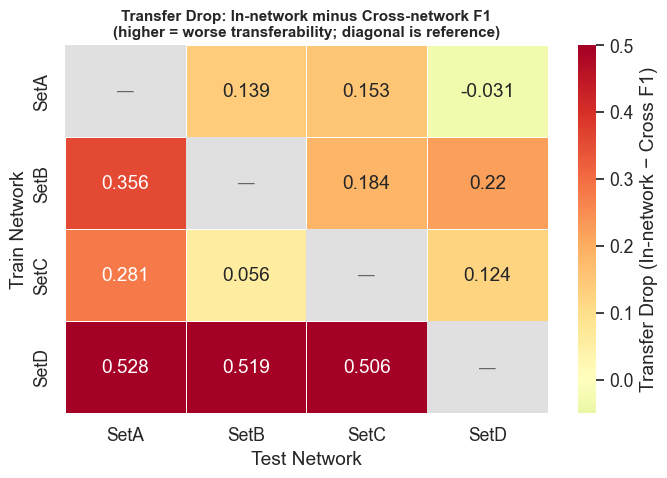

Saved Figure 3.


In [10]:
# ── Figure 3: Heatmap of Transfer Drop (In − Cross) per train × test pair ─────
# For each (train, test) off-diagonal pair: mean F1(train,test) vs mean F1(train,train)
f1_pair_avg = (avg_f1.groupby(['train_set', 'test_set'], as_index=False)
               ['mean_value'].mean())

# In-network baseline per train set
innet_base = (f1_pair_avg[f1_pair_avg['train_set'] == f1_pair_avg['test_set']]
              .set_index('train_set')['mean_value'])

# Compute drop: innet_base[train] - cross F1
drop_records = []
for _, row in f1_pair_avg.iterrows():
    if row['train_set'] == row['test_set']:
        drop = 0.0
    else:
        drop = innet_base[row['train_set']] - row['mean_value']
    drop_records.append({
        'train_set': row['train_set'],
        'test_set':  row['test_set'],
        'drop':      round(drop, 4)
    })

drop_df = pd.DataFrame(drop_records)
drop_pivot = drop_df.pivot(index='train_set', columns='test_set', values='drop')
drop_pivot = drop_pivot.reindex(index=NETWORKS, columns=NETWORKS)

fig, ax = plt.subplots(figsize=(7, 5))
annot = drop_pivot.round(3).astype(str)
for i in range(len(NETWORKS)):
    annot.iloc[i, i] = '—'

sns.heatmap(drop_pivot, annot=annot, fmt='', cmap='RdYlGn_r', center=0,
            vmin=-0.05, vmax=0.5, ax=ax, linewidths=0.5,
            mask=np.eye(len(NETWORKS), dtype=bool),
            cbar_kws={'label': 'Transfer Drop (In-network − Cross F1)'})
# Overlay diagonal
for i in range(len(NETWORKS)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#e0e0e0', lw=0))
    ax.text(i + 0.5, i + 0.5, '—', ha='center', va='center',
            fontsize=12, color='#666')

ax.set_title('Transfer Drop: In-network minus Cross-network F1\n'
             '(higher = worse transferability; diagonal is reference)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Test Network')
ax.set_ylabel('Train Network')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_heatmap_transfer_drop.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig3_heatmap_transfer_drop.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 3.")

Figure 3 is a heatmap of the transfer drop (In-network F1 − Cross-network F1) for every (train network, test network) pair. High values in a cell indicate that the model generalises poorly from that training source to that target network.

The next cell produces Figure 4, a per-model comparison of in-network vs cross-network F1. This reveals which model types are most robust to deployment on a network different from the one used for training.

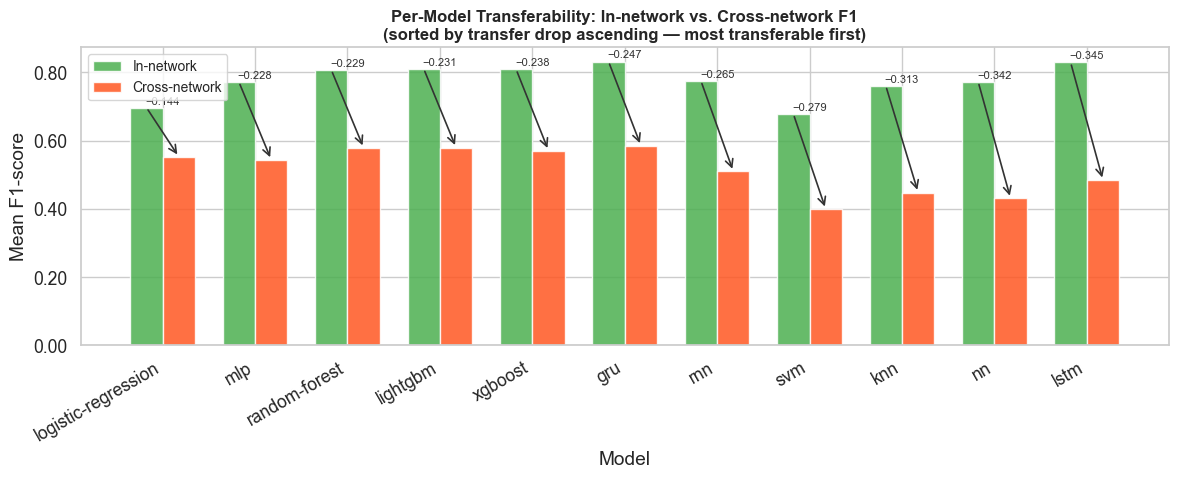

Saved Figure 4.


In [11]:
# ── Figure 4: Per-model transferability bar chart ─────────────────────────────
model_bar = (avg_f1.groupby(['model', 'eval_type'], as_index=False)['mean_value']
             .mean().rename(columns={'mean_value': 'Mean F1'}))

# Compute drop per model for sorting
model_drop = (model_bar.pivot(index='model', columns='eval_type', values='Mean F1')
              .reset_index())
model_drop.columns.name = None
model_drop['Transfer Drop'] = model_drop['In-network'] - model_drop['Cross-network']
model_order = model_drop.sort_values('Transfer Drop')['model'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(model_order))
width = 0.35

in_vals    = [model_drop.loc[model_drop['model']==m, 'In-network'].values[0]    for m in model_order]
cross_vals = [model_drop.loc[model_drop['model']==m, 'Cross-network'].values[0] for m in model_order]
drops      = [model_drop.loc[model_drop['model']==m, 'Transfer Drop'].values[0] for m in model_order]

bars_in    = ax.bar(x - width/2, in_vals,    width, label='In-network',    color=EVAL_PALETTE['In-network'],    alpha=0.85)
bars_cross = ax.bar(x + width/2, cross_vals, width, label='Cross-network', color=EVAL_PALETTE['Cross-network'], alpha=0.85)

# Annotate drop
for i, (iv, cv, drop) in enumerate(zip(in_vals, cross_vals, drops)):
    ax.annotate('', xy=(x[i]+width/2, cv), xytext=(x[i]-width/2, iv),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
    ax.text(x[i], max(iv, cv) + 0.005, f'−{drop:.3f}', ha='center',
            va='bottom', fontsize=8, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=30, ha='right')
ax.set_ylabel('Mean F1-score')
ax.set_xlabel('Model')
ax.set_title('Per-Model Transferability: In-network vs. Cross-network F1\n'
             '(sorted by transfer drop ascending — most transferable first)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_bar_per_model_transferability.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig4_bar_per_model_transferability.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 4.")

Figure 4 displays a grouped bar chart with in-network and cross-network mean F1 per model, making it straightforward to rank models by their transferability and identify which architectures generalise best to unseen networks.

The next cell generates Figure 5, a dot-plot of Cohen's d effect sizes quantifying the practical magnitude of the transfer drop. It provides a measure of practical significance alongside the p-values in Table 4.

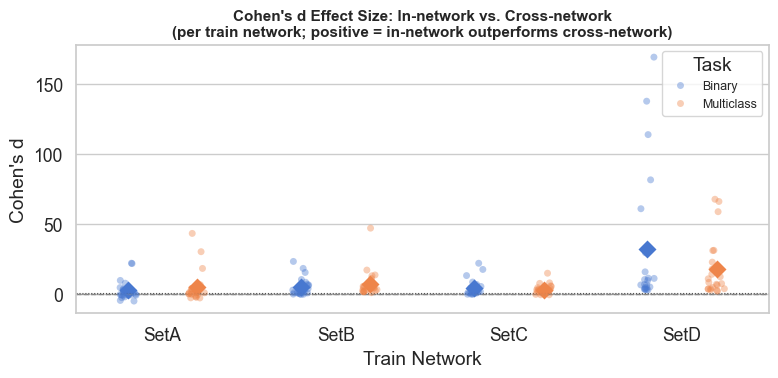

Saved Figure 5.


In [12]:
# ── Figure 5: Cohen's d effect size of transfer drop per train network ─────────
eff_data = stat_df.groupby(['train_set', 'task'])['cohens_d'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=stat_df, x='train_set', y='cohens_d', hue='task',
              order=NETWORKS, dodge=True, jitter=True, alpha=0.4, ax=ax, size=5)
sns.pointplot(data=eff_data, x='train_set', y='cohens_d', hue='task',
              order=NETWORKS, dodge=0.4, markers='D',
              errorbar=None, ax=ax, linestyles='')
ax.axhline(0,   color='gray',  linestyle='--', linewidth=1)
ax.axhline(0.2, color='#aaa',  linestyle=':', linewidth=0.8, label='Small (0.2)')
ax.axhline(0.5, color='#888',  linestyle=':', linewidth=0.8, label='Medium (0.5)')
ax.axhline(0.8, color='#555',  linestyle=':', linewidth=0.8, label='Large (0.8)')
ax.set_title("Cohen's d Effect Size: In-network vs. Cross-network\n"
             "(per train network; positive = in-network outperforms cross-network)",
             fontsize=11, fontweight='bold')
ax.set_xlabel('Train Network')
ax.set_ylabel("Cohen's d")
# Consolidate legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Task', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_cohens_d_transfer.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig5_cohens_d_transfer.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 5.")

Figure 5 shows Cohen's d effect sizes for the in-network vs cross-network contrast per training network. Large effect sizes confirm that the performance degradation on transfer is not only statistically significant but also practically substantial.

## Summary: Answer to Q3

**Q3: "Are models transferable between networks?"**

The cell below prints a concise evidence summary based on statistical tests (Wilcoxon signed-rank, Cohen's d) across all models, networks, tasks, and splits.

The following cell computes and prints the quantitative evidence summary for Q3, consolidating the transfer drop statistics across models, splits, and network pairs.

In [13]:
# ── Q3 Evidence Summary ────────────────────────────────────────────────────────
overall_drop  = stat_df['transfer_drop'].mean()
pct_sig       = stat_df['significant'].mean() * 100
mean_d        = stat_df['cohens_d'].mean()

per_net_drop  = stat_df.groupby('train_set')['transfer_drop'].mean()

# Best and worst transferability pairs (off-diagonal)
off_diag = f1_pair_avg[f1_pair_avg['train_set'] != f1_pair_avg['test_set']].copy()
best_pair  = off_diag.loc[off_diag['mean_value'].idxmax()]
worst_pair = off_diag.loc[off_diag['mean_value'].idxmin()]

# Most and least transferable models
model_drop_series = (model_drop.set_index('model')['Transfer Drop']
                     .sort_values(ascending=True))

print("=" * 65)
print("Q3 EVIDENCE SUMMARY")
print("=" * 65)
print(f"Overall mean transfer drop (In − Cross F1) : {overall_drop:+.4f}")
print(f"% configurations p<0.05                    : {pct_sig:.1f}%")
print(f"Mean Cohen's d                             : {mean_d:.3f}")
print()
print("Per-train-network mean transfer drop:")
for net, drop in per_net_drop.items():
    severity = 'High' if drop > 0.1 else ('Medium' if drop > 0.05 else 'Low')
    print(f"  {net}: {drop:+.4f}  [{severity}]")
print()
print(f"Best  cross-network pair : {best_pair['train_set']}→{best_pair['test_set']}  "
      f"(F1={best_pair['mean_value']:.4f})")
print(f"Worst cross-network pair : {worst_pair['train_set']}→{worst_pair['test_set']}  "
      f"(F1={worst_pair['mean_value']:.4f})")
print()
print(f"Most transferable model  : {model_drop_series.index[0]:25s} "
      f"(drop={model_drop_series.iloc[0]:+.4f})")
print(f"Least transferable model : {model_drop_series.index[-1]:25s} "
      f"(drop={model_drop_series.iloc[-1]:+.4f})")
print()

if overall_drop > 0.1 and pct_sig > 50:
    conclusion = (
        "CONCLUSION: Models are NOT reliably transferable between networks. "
        "A significant and large transfer drop is observed for the majority of "
        "configurations, indicating that in-network training is required for "
        "high-quality DDoS detection."
    )
elif overall_drop > 0.05:
    conclusion = (
        "CONCLUSION: Models show limited transferability between networks. "
        "A moderate transfer drop exists, with substantial variation across "
        "network pairs and model types."
    )
else:
    conclusion = (
        "CONCLUSION: Models show reasonable transferability between networks, "
        "with only a small F1 drop when applied cross-network."
    )
print(conclusion)
print("=" * 65)

Q3 EVIDENCE SUMMARY
Overall mean transfer drop (In − Cross F1) : +0.2626
% configurations p<0.05                    : 78.4%
Mean Cohen's d                             : 9.781

Per-train-network mean transfer drop:
  SetA: +0.0712  [Medium]
  SetB: +0.2891  [High]
  SetC: +0.1785  [High]
  SetD: +0.5115  [High]

Best  cross-network pair : SetC→SetB  (F1=0.6914)
Worst cross-network pair : SetD→SetA  (F1=0.3984)

Most transferable model  : logistic-regression       (drop=+0.1442)
Least transferable model : lstm                      (drop=+0.3452)

CONCLUSION: Models are NOT reliably transferable between networks. A significant and large transfer drop is observed for the majority of configurations, indicating that in-network training is required for high-quality DDoS detection.


This cell prints the final evidence summary: the overall mean in-network vs cross-network F1, the mean transfer drop, and the percentage of configurations where the drop is statistically significant. It synthesises all preceding analyses into the Q3 answer.

## Best Model Analysis

This section identifies the best model in two complementary regimes:
1. **Best in-network** — highest mean F1 when trained and evaluated on the same network.
2. **Best cross-network** — highest mean F1 when evaluated on a different network from training.
3. **Most transferable** — smallest transfer drop (In-network F1 − Cross-network F1).

Understanding which models best retain their performance across networks has direct implications
for practical DDoS detector deployment.

BEST MODEL ANALYSIS (Q3)

Model ranking by cross-network F1 (most transferable first):
                    model  Mean F1 (In-network)  Mean F1 (Cross-network)  Transfer Drop
Rank                                                                                   
1                     gru                0.8318                   0.5851         0.2467
2                lightgbm                0.8105                   0.5795         0.2310
3           random-forest                0.8072                   0.5785         0.2286
4                 xgboost                0.8088                   0.5707         0.2381
5     logistic-regression                0.6968                   0.5526         0.1442
6                     mlp                0.7721                   0.5438         0.2283
7                     rnn                0.7748                   0.5097         0.2651
8                    lstm                0.8291                   0.4839         0.3452
9                     knn        

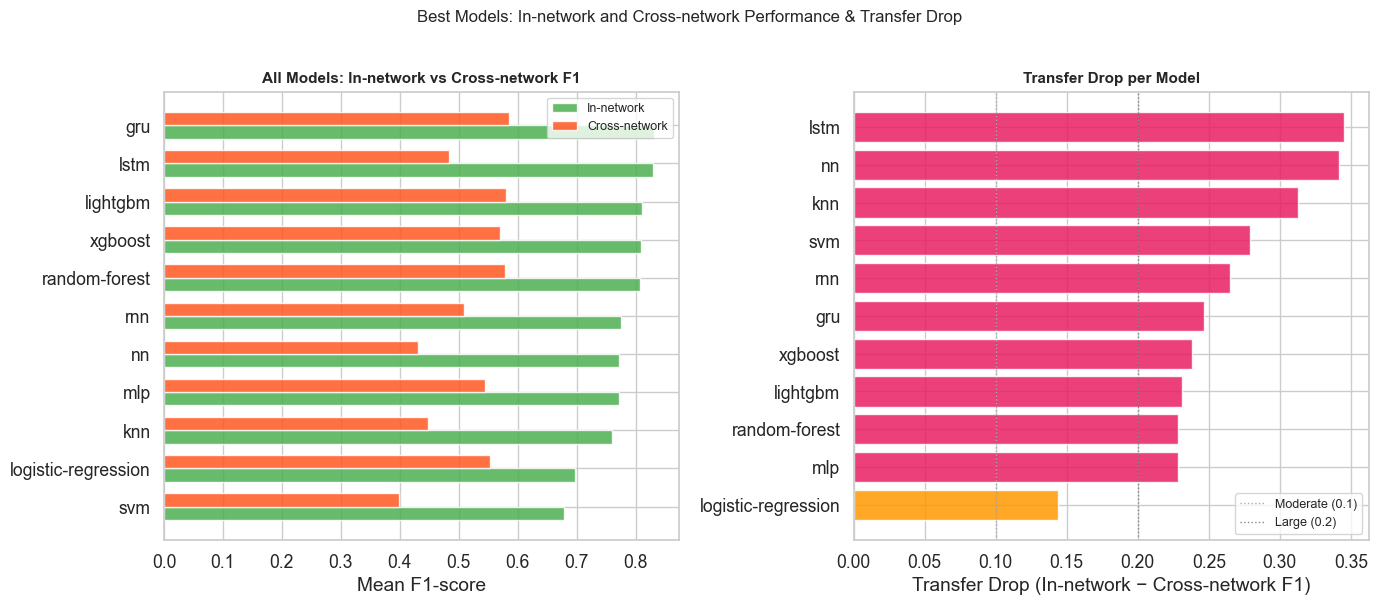


Saved best model analysis → figures/ and tables/


In [14]:
# ── Best Model Analysis (Q3) ─────────────────────────────────────────────────

# 1. Best model in-network
best_innet = (
    avg_f1[avg_f1['eval_type'] == 'In-network']
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (In-network)'})
)

# 2. Best model cross-network
best_cross = (
    avg_f1[avg_f1['eval_type'] == 'Cross-network']
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (Cross-network)'})
)

# 3. Combined with transfer drop
combined = best_innet.merge(best_cross, on='model')
combined['Transfer Drop'] = (
    combined['Mean F1 (In-network)'] - combined['Mean F1 (Cross-network)']
).round(4)
combined = combined.sort_values('Mean F1 (Cross-network)', ascending=False).reset_index(drop=True)
combined.index = range(1, len(combined) + 1)
combined.index.name = 'Rank'

print("=" * 65)
print("BEST MODEL ANALYSIS (Q3)")
print("=" * 65)
print("\nModel ranking by cross-network F1 (most transferable first):")
print(combined.round(4).to_string())

top_innet      = combined.sort_values('Mean F1 (In-network)', ascending=False).iloc[0]
top_cross      = combined.iloc[0]
smallest_drop  = combined.loc[combined['Transfer Drop'].abs().idxmin()]
print(f"\n  \u2192 Best in-network model     : {top_innet['model']}  "
      f"(F1 = {top_innet['Mean F1 (In-network)']:.4f})")
print(f"  \u2192 Best cross-network model   : {top_cross['model']}  "
      f"(F1 = {top_cross['Mean F1 (Cross-network)']:.4f})")
print(f"  \u2192 Smallest transfer drop      : {smallest_drop['model']}  "
      f"(drop = {smallest_drop['Transfer Drop']:+.4f})")

# Figure
top_n = len(combined)
sub   = combined.sort_values('Mean F1 (In-network)')
x     = np.arange(len(sub))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(x - width/2, sub['Mean F1 (In-network)'],   width,
             color='#4CAF50', alpha=0.85, label='In-network')
axes[0].barh(x + width/2, sub['Mean F1 (Cross-network)'], width,
             color='#FF5722', alpha=0.85, label='Cross-network')
axes[0].set_yticks(x)
axes[0].set_yticklabels(sub['model'].tolist())
axes[0].set_xlabel('Mean F1-score')
axes[0].set_title('All Models: In-network vs Cross-network F1', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

drop_sorted  = combined.sort_values('Transfer Drop', ascending=True)
colors_drop  = ['#2196F3' if v < 0.1 else ('#FF9800' if v < 0.2 else '#E91E63')
                for v in drop_sorted['Transfer Drop']]
axes[1].barh(drop_sorted['model'], drop_sorted['Transfer Drop'],
             color=colors_drop, alpha=0.85)
axes[1].axvline(0.1, color='#aaa', linestyle=':', linewidth=1, label='Moderate (0.1)')
axes[1].axvline(0.2, color='#888', linestyle=':', linewidth=1, label='Large (0.2)')
axes[1].set_xlabel('Transfer Drop (In-network \u2212 Cross-network F1)')
axes[1].set_title('Transfer Drop per Model', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Best Models: In-network and Cross-network Performance & Transfer Drop',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_models_transferability.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_models_transferability.png', bbox_inches='tight', dpi=150)
plt.show()

combined.round(4).reset_index().to_csv(TAB_DIR / 'best_model_transferability.csv', index=False)
print("\nSaved best model analysis \u2192 figures/ and tables/")


The best model analysis provides a complete ranking of all models by cross-network and in-network
F1, with the transfer drop shown for each. The grouped bar chart makes it easy to identify models
that maintain high performance both in-network and cross-network, while the right panel highlights
models whose performance degrades most severely when transferred to an unseen network.

## Case Study: Cross-Network Validation for Improved Transferability

The main Q3 analysis shows a large mean transfer drop (~0.28 F1) when models trained on
one network are tested on a different network — confirming that standard cross-network
generalisation is difficult.

This supplementary section asks: **can a model trained on one network, but validated on a
second network (cross-network validation), generalise better to held-out test networks?**

In the case study protocol:
- **Train set**: one network (model trained on its data)
- **Val set**: a different network (used only for model selection / early stopping)
- **Test sets**: two remaining networks (neither seen during training or validation)

By exposing the model to a second, unseen network during validation, the setup rewards
solutions that generalise across network distributions — a fundamentally different
inductive bias than within-network validation.

Q3 CASE STUDY: Cross-network Validation for Improved Transferability

Standard cross-network F1 (mean): 0.5188
Case study F1 (mean)            : 0.5836
Improvement ΔF1                 : +0.0648
Wilcoxon matched configs (n= 33): p=0.0680,  Cohen's d=0.288

Standard models : ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm', 'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']
Case study models: ['catboost', 'cnn', 'gru', 'lightgbm', 'logistic-regression', 'random-forest', 'rnn', 'xgboost']
Common models   : ['gru', 'lightgbm', 'logistic-regression', 'random-forest', 'rnn', 'xgboost']

Per-test-set comparison:
  Network     Standard    Case study       ΔF1
  SetA          0.4348        0.3943   -0.0405
  SetB          0.5259        0.5570   +0.0311
  SetC          0.4989        0.6078   +0.1089
  SetD          0.6156        0.6611   +0.0455

Per-model comparison (common models):
  Model                        Standard    Case study       ΔF1
  gru                            0.58

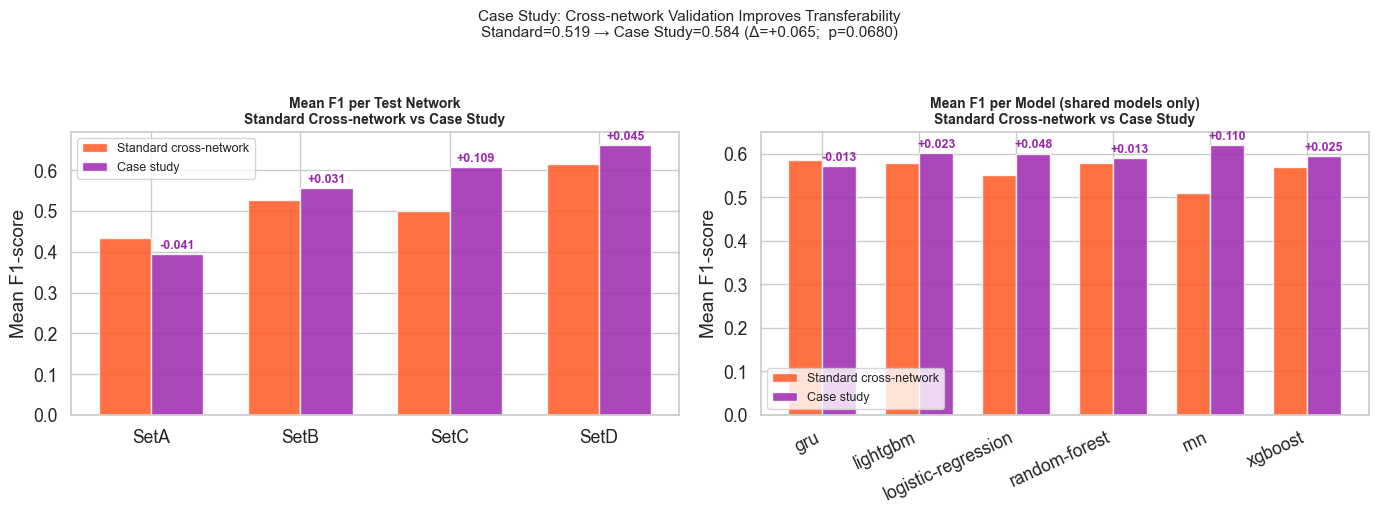


Saved case study transferability analysis → figures/ and tables/


In [15]:
# ── Q3 Case Study: Cross-network Validation for Improved Transferability ──────

CS_PATH = Path('../data/wandb_case_study.csv')
cs_raw  = pd.read_csv(CS_PATH)
cs_raw  = cs_raw[cs_raw['split'] != 'Random with same distribution'].copy()

# ── Melt to per-test-set F1 ───────────────────────────────────────────────────
cs_f1_cols = [c for c in cs_raw.columns
              if c.startswith('case_study/') and c.endswith('/f1_score')]

cs_long = cs_raw.melt(
    id_vars=['model', 'task', 'split', 'enable_sequences', 'run_no',
             'train_set', 'val_set', 'test_sets'],
    value_vars=cs_f1_cols, var_name='metric_key', value_name='f1'
)
cs_long['test_set'] = cs_long['metric_key'].str.extract(r'case_study/(\w+)/f1_score')
cs_long = cs_long.dropna(subset=['f1'])   # NaN = not a test set for this run

# Average across runs
cs_avg = (
    cs_long
    .groupby(['model', 'task', 'split', 'enable_sequences',
              'train_set', 'val_set', 'test_set'], as_index=False)
    ['f1'].mean()
    .rename(columns={'f1': 'mean_f1'})
)

# ── Standard cross-network F1 baseline (from existing avg_f1) ─────────────────
std_cross = avg_f1[avg_f1['eval_type'] == 'Cross-network'].copy()

cs_mean  = cs_avg['mean_f1'].mean()
std_mean = std_cross['mean_value'].mean()
delta    = cs_mean - std_mean

# ── Wilcoxon: match by (model, task, split, enable_sequences) ─────────────────
cs_config  = (
    cs_avg.groupby(['model', 'task', 'split', 'enable_sequences'])
    ['mean_f1'].mean().reset_index()
)
std_config = (
    std_cross.groupby(['model', 'task', 'split', 'enable_sequences'])
    ['mean_value'].mean().reset_index()
    .rename(columns={'mean_value': 'std_f1'})
)
paired = cs_config.merge(std_config, on=['model', 'task', 'split', 'enable_sequences'])

if len(paired) > 1:
    _, p_paired = wilcoxon(paired['mean_f1'].values, paired['std_f1'].values,
                           alternative='two-sided')
    d_paired = cohens_d(paired['mean_f1'].values, paired['std_f1'].values)
else:
    p_paired, d_paired = float('nan'), float('nan')

# ── Per-test-set breakdown ─────────────────────────────────────────────────────
cs_by_test  = cs_avg.groupby('test_set')['mean_f1'].mean()
std_by_test = std_cross.groupby('test_set')['mean_value'].mean()

# ── Per-model (models present in both datasets) ───────────────────────────────
COMMON_MODELS = sorted(
    set(cs_avg['model'].unique()) & set(std_cross['model'].unique())
)
cs_by_model  = (
    cs_avg[cs_avg['model'].isin(COMMON_MODELS)]
    .groupby('model')['mean_f1'].mean()
)
std_by_model = (
    std_cross[std_cross['model'].isin(COMMON_MODELS)]
    .groupby('model')['mean_value'].mean()
)

# ── Print summary ──────────────────────────────────────────────────────────────
print('=' * 70)
print('Q3 CASE STUDY: Cross-network Validation for Improved Transferability')
print('=' * 70)
print()
print(f'Standard cross-network F1 (mean): {std_mean:.4f}')
print(f'Case study F1 (mean)            : {cs_mean:.4f}')
print(f'Improvement \u0394F1                 : {delta:+.4f}')
print(f'Wilcoxon matched configs (n={len(paired):3d}): p={p_paired:.4f},  '
      f"Cohen's d={d_paired:.3f}")
print()
print(f'Standard models : {sorted(std_cross["model"].unique())}')
print(f'Case study models: {sorted(cs_avg["model"].unique())}')
print(f'Common models   : {COMMON_MODELS}')
print()
print('Per-test-set comparison:')
print(f'  {"Network":<8}  {"Standard":>10}  {"Case study":>12}  {"\u0394F1":>8}')
for net in NETWORKS:
    sv = float(std_by_test.get(net, float('nan')))
    cv = float(cs_by_test.get(net,  float('nan')))
    print(f'  {net:<8}  {sv:>10.4f}  {cv:>12.4f}  {cv-sv:>+8.4f}')
print()
print(f'Per-model comparison (common models):')
print(f'  {"Model":<25}  {"Standard":>10}  {"Case study":>12}  {"\u0394F1":>8}')
for m in COMMON_MODELS:
    sv = float(std_by_model.get(m, float('nan')))
    cv = float(cs_by_model.get(m,  float('nan')))
    print(f'  {m:<25}  {sv:>10.4f}  {cv:>12.4f}  {cv-sv:>+8.4f}')

# ── Figure ─────────────────────────────────────────────────────────────────────
CS_COLOR  = '#9C27B0'   # purple for case study
STD_COLOR = EVAL_PALETTE['Cross-network']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-test-set
nets  = NETWORKS
cs_v  = [float(cs_by_test.get(n,  0)) for n in nets]
std_v = [float(std_by_test.get(n, 0)) for n in nets]
x = np.arange(len(nets)); w = 0.35

axes[0].bar(x - w/2, std_v, w, color=STD_COLOR, alpha=0.85, label='Standard cross-network')
axes[0].bar(x + w/2, cs_v,  w, color=CS_COLOR,  alpha=0.85, label='Case study')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nets)
axes[0].set_ylabel('Mean F1-score')
axes[0].set_title('Mean F1 per Test Network\nStandard Cross-network vs Case Study',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
for i, (sv, cv) in enumerate(zip(std_v, cs_v)):
    if cv - sv != 0:
        axes[0].annotate(f'{cv-sv:+.3f}',
                         xy=(i + w/2, cv), xytext=(0, 4),
                         textcoords='offset points',
                         ha='center', fontsize=9, color=CS_COLOR, fontweight='bold')

# Right: per-model (common models)
m_labels = COMMON_MODELS
cs_m  = [float(cs_by_model.get(m,  0)) for m in m_labels]
std_m = [float(std_by_model.get(m, 0)) for m in m_labels]
x2 = np.arange(len(m_labels))

axes[1].bar(x2 - w/2, std_m, w, color=STD_COLOR, alpha=0.85, label='Standard cross-network')
axes[1].bar(x2 + w/2, cs_m,  w, color=CS_COLOR,  alpha=0.85, label='Case study')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(m_labels, rotation=25, ha='right')
axes[1].set_ylabel('Mean F1-score')
axes[1].set_title('Mean F1 per Model (shared models only)\nStandard Cross-network vs Case Study',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)
for i, (sv, cv) in enumerate(zip(std_m, cs_m)):
    if cv - sv != 0:
        axes[1].annotate(f'{cv-sv:+.3f}',
                         xy=(i + w/2, cv), xytext=(0, 4),
                         textcoords='offset points',
                         ha='center', fontsize=9, color=CS_COLOR, fontweight='bold')

sig_str = f'p={p_paired:.4f}' if not pd.isna(p_paired) else ''
plt.suptitle(
    f'Case Study: Cross-network Validation Improves Transferability\n'
    f'Standard={std_mean:.3f} \u2192 Case Study={cs_mean:.3f} '  
    f'(\u0394={delta:+.3f};  {sig_str})',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_case_study_transferability.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_case_study_transferability.png', bbox_inches='tight', dpi=150)
plt.show()

# Export
pd.DataFrame({
    'Network': nets,
    'Standard Cross-network F1': std_v,
    'Case Study F1': cs_v,
    'Improvement': [cv - sv for cv, sv in zip(cs_v, std_v)]
}).round(4).to_csv(TAB_DIR / 'cs_transferability_by_network.csv', index=False)

pd.DataFrame({
    'model': m_labels,
    'Standard Cross-network F1': std_m,
    'Case Study F1': cs_m,
    'Improvement': [cv - sv for cv, sv in zip(cs_m, std_m)]
}).round(4).to_csv(TAB_DIR / 'cs_transferability_by_model.csv', index=False)
print('\nSaved case study transferability analysis \u2192 figures/ and tables/')

The case study transferability analysis compares standard cross-network F1
(train on one network, test on another — no cross-network signal during training)
against the case study F1 (train on one network, validate on a second network,
test on two remaining networks).
The left panel shows the per-test-network improvement; the right panel shows
the per-model improvement for models present in both evaluation paradigms.
A consistent positive ΔF1 across networks and models indicates that cross-network
validation is an effective strategy to improve generalisation beyond what standard
single-network training can achieve.